<a href="https://colab.research.google.com/github/Saswat545/CODSOFT/blob/main/Task_2_Movie_Rating/Movie_Rating_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("IMDb Movies India.csv", encoding="latin1")

In [3]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [5]:
df = df.dropna(subset=["Rating"])

In [6]:
df["Year"] = df["Year"].str.extract("(\d{4})")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-2520938570.py:1: SyntaxWarning: invalid escape sequence '\d'
  df["Year"] = df["Year"].str.extract("(\d{4})")


In [7]:
df["Duration"] = df["Duration"].str.replace(" min", "")
df["Duration"] = pd.to_numeric(df["Duration"], errors="coerce")

In [8]:
df["Votes"] = df["Votes"].str.replace(",", "")
df["Votes"] = pd.to_numeric(df["Votes"], errors="coerce")

In [9]:
df = df.dropna()

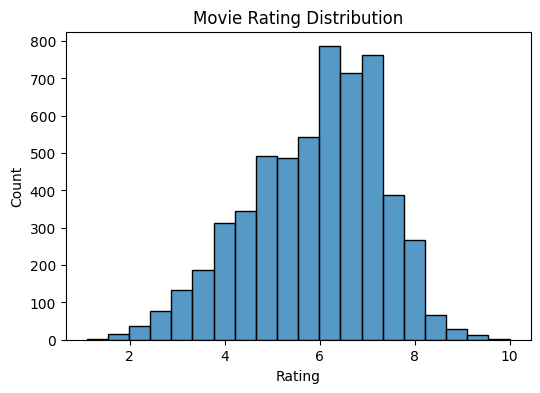

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df["Rating"], bins=20)
plt.title("Movie Rating Distribution")
plt.show()

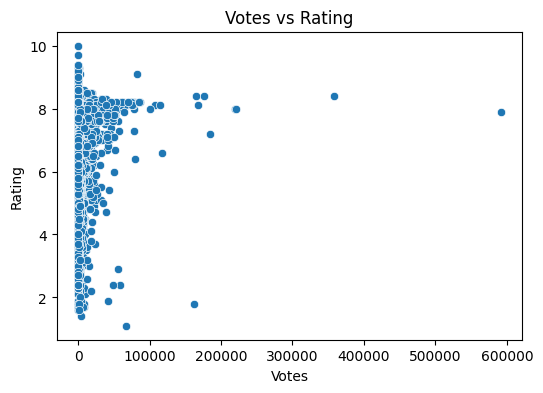

In [11]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Votes"], y=df["Rating"])
plt.title("Votes vs Rating")
plt.show()

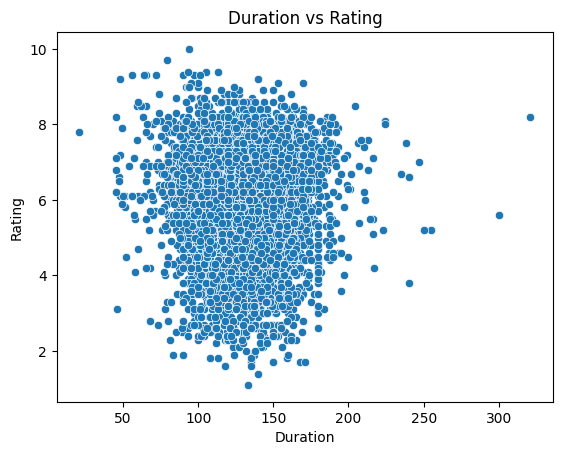

In [12]:
sns.scatterplot(x=df["Duration"], y=df["Rating"])
plt.title("Duration vs Rating")
plt.show()

In [13]:
features = df[["Year", "Duration", "Votes"]]
target = df["Rating"]

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


Mean Absolute Error: 1.060606221312931
R2 Score: 0.07798737059748762
